<a href="https://colab.research.google.com/github/srikanth713/codealpha_tasks/blob/main/Handwritten_text_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Character Recognition with CNN (MNIST Dataset)

This notebook demonstrates a complete workflow for building a Convolutional Neural Network (CNN) to recognize handwritten digits using the MNIST dataset. This project is part of the CodeAlpha Machine Learning Internship.

In [ ]:
# 1. Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import joblib
from google.colab import files

## 2. Load the MNIST Dataset

We will load the MNIST dataset directly from Keras. This dataset consists of 60,000 training images and 10,000 testing images of handwritten digits (0-9).

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


## 3. Data Preprocessing

Data preprocessing steps include:
- **Normalization**: Scaling pixel values from [0, 255] to [0, 1] to help the model converge faster and perform better.
- **Reshaping**: Reshaping the images to add a channel dimension, which is required for Conv2D layers in Keras (e.g., `(28, 28)` to `(28, 28, 1)` for grayscale images).

In [ ]:
# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images for CNN input: (batch_size, height, width, channels)
# MNIST images are grayscale, so they have 1 channel.
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

print(f"Reshaped training data shape: {x_train.shape}")
print(f"Reshaped testing data shape: {x_test.shape}")

Reshaped training data shape: (60000, 28, 28, 1)
Reshaped testing data shape: (10000, 28, 28, 1)


## 4. Build a Convolutional Neural Network (CNN)

We will construct a sequential CNN model with the following layers:
- **Conv2D layers**: To learn spatial hierarchies of patterns.
- **MaxPooling2D layers**: To downsample the feature maps, reducing dimensionality and computation.
- **Flatten layer**: To convert the 2D feature maps into a 1D feature vector.
- **Dense layers**: Fully connected layers for classification.
- **Softmax output layer**: To output probabilities for each of the 10 digit classes.

In [ ]:
# Build the CNN model
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the output to feed into Dense layers
    layers.Flatten(),

    # Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for digits 0-9
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

We will train the CNN model using the `x_train` and `y_train` data. The training will run for 5 epochs, and validation will be performed on the `x_test` and `y_test` data.

In [ ]:
# Train the model for 5 epochs
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

print("\nModel training complete.")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.9602 - loss: 0.1315 - val_accuracy: 0.9859 - val_loss: 0.0423
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9869 - loss: 0.0422 - val_accuracy: 0.9854 - val_loss: 0.0424
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 29ms/step - accuracy: 0.9911 - loss: 0.0290 - val_accuracy: 0.9894 - val_loss: 0.0312
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9930 - loss: 0.0217 - val_accuracy: 0.9886 - val_loss: 0.0365
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 34ms/step - accuracy: 0.9948 - loss: 0.0154 - val_accuracy: 0.9923 - val_loss: 0.0266

Model training complete.


## 6. Evaluate the Model

After training, we will evaluate the model's performance on the unseen test dataset to determine its accuracy and loss.

In [ ]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 0.9923
Test Loss: 0.0266


## 7. Display Sample Predictions

We will visualize a few test images, their true labels, and the model's predicted labels to understand its performance qualitatively.

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


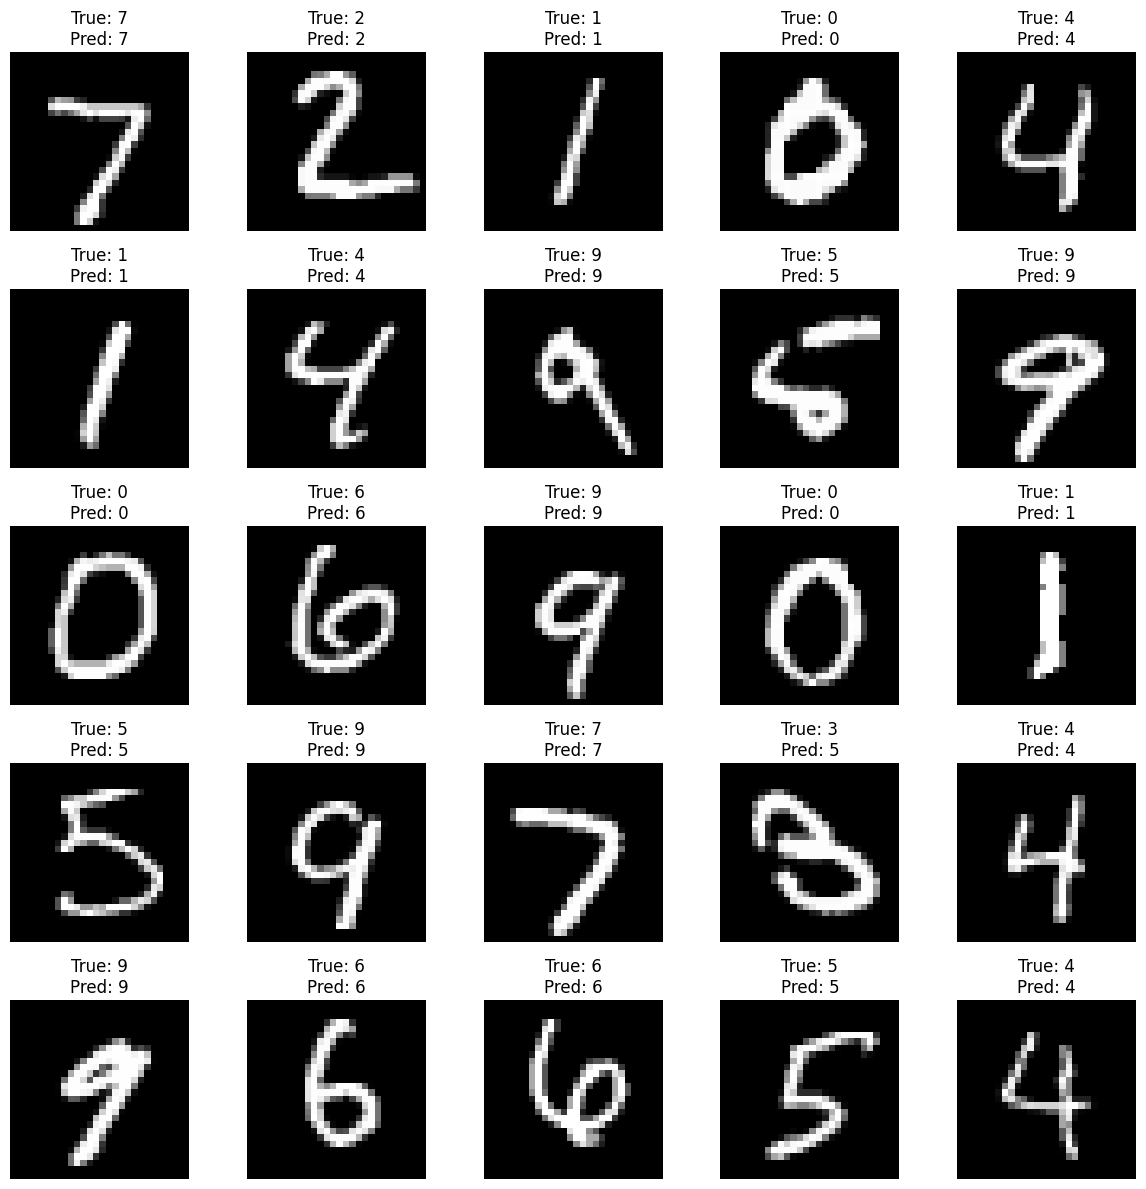

In [ ]:
# Make predictions on the test set
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

# Display sample predictions
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_test[i]}\nPred: {predicted_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 8. Plot Training History

We will plot the training and validation accuracy and loss over epochs to visualize the model's learning process and identify potential overfitting or underfitting.

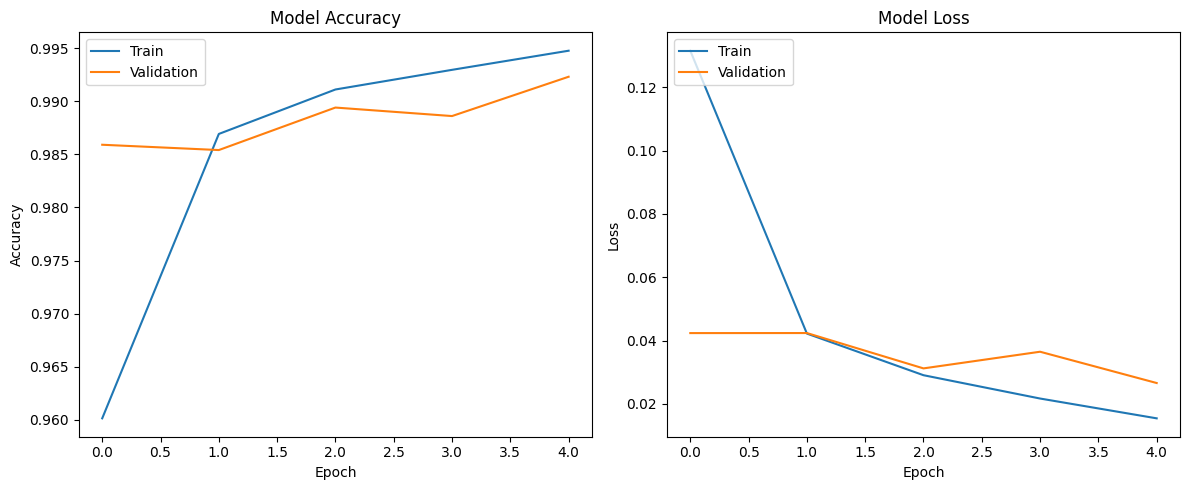

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

## 9. Generate a Confusion Matrix

A confusion matrix will help us understand the performance of our classification model by showing the number of correct and incorrect predictions for each class.

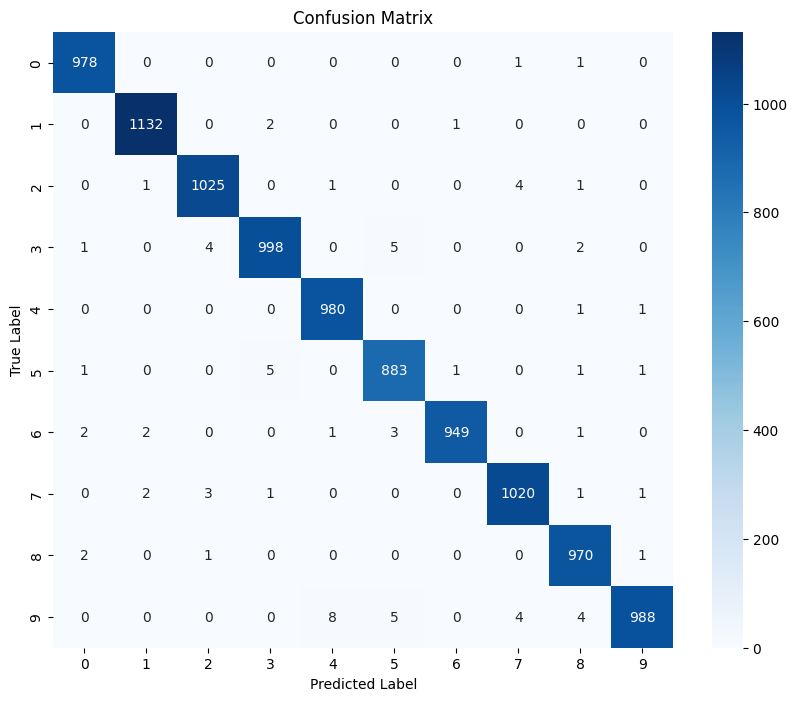

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 10 & 11. Save and Download the Model

Finally, we will save the trained model using Joblib and provide code to automatically download the saved model file.

In [ ]:
# Save the trained model as a Joblib file
model_filename = 'handwritten_character_recognition_model.joblib'
joblib.dump(model, model_filename)
print(f"Model saved as {model_filename}")

# Download the Joblib file
files.download(model_filename)
print(f"{model_filename} downloaded successfully.")

Model saved as handwritten_character_recognition_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

handwritten_character_recognition_model.joblib downloaded successfully.
